In [ ]:
%load_ext autoreload
%autoreload 2

<div style="text-align: right;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/HdM_Logo.svg/100px-HdM_Logo.svg.png"
       alt="HdM Logo"
       width="120">
</div>

# Draft analysis 

---

Annette Kufner

---


## 1. Einleitung

In [64]:
import pandas as pd
import plotly.graph_objects as go

# ----------------------------------------------------------------------------------
# DATEN
# ----------------------------------------------------------------------------------
data = {
    "City": ["Albany", "Asheville", "Austin", "Boston", "Bozeman", "Chicago", "Columbus", "Dallas", 
             "Denver", "Fort Worth", "Los Angeles", "Nashville", "New Orleans", "New York City", 
             "Portland", "San Diego", "San Francisco", "Seattle", "Washington, D.C."],
    "State": ["NY", "NC", "TX", "MA", "MT", "IL", "OH", "TX", "CO", "TX", "CA", "TN", "LA", "NY", 
              "OR", "CA", "CA", "WA", "DC"],
    "Lat": [42.6526, 35.5951, 30.2672, 42.3601, 45.6770, 41.8781, 39.9612, 32.7767, 39.7392, 32.7555, 
            34.0522, 36.1627, 29.9511, 40.7128, 45.5152, 32.7157, 37.7749, 47.6062, 38.9072],
    "Lon": [-73.7562, -82.5515, -97.7431, -71.0589, -111.0429, -87.6298, -90.0715, -96.7970, 
            -104.9903, -97.3308, -118.2437, -86.7816, -90.0715, -74.0060, -122.6784, -117.1611, 
            -122.4194, -122.3321, -77.0369]
}

df = pd.DataFrame(data)

# ----------------------------------------------------------------------------------
# Text-Offsets individuell setzen, um Überlappungen zu vermeiden
# ----------------------------------------------------------------------------------
df['TextPosition'] = 'middle right'
df['TextDx'] = 2
df['TextDy'] = 0   # vertikaler Offset

# Spezielle Anpassungen für problematische Städte
df.loc[df['City'] == 'Boston', ['TextPosition','TextDx','TextDy']] = ['middle left', -10, 5]
df.loc[df['City'] == 'Dallas', 'TextDx'] = 10
df.loc[df['City'] == 'Fort Worth', ['TextPosition','TextDx','TextDy']] = ['middle left', -10, -5]
df.loc[df['City'] == 'Albany', ['TextPosition','TextDx','TextDy']] = ['top right', 5, 5]

# ----------------------------------------------------------------------------------
# Markerfarbe und -größe nach Stadt
# ----------------------------------------------------------------------------------
df['MarkerColor'] = '#FF6F61'   # Standardfarbe
df['MarkerSize'] = 10            # Standardgröße

# NYC hervorheben
df.loc[df['City'] == 'New York City', 'MarkerColor'] = 'teal'
df.loc[df['City'] == 'New York City', 'MarkerSize'] = 16

# ----------------------------------------------------------------------------------
# Plotly Karte
# ----------------------------------------------------------------------------------
fig = go.Figure(data=[
    go.Scattergeo(
        locationmode='USA-states',
        lat=df['Lat'],
        lon=df['Lon'],
        mode='markers+text',
        marker=dict(
            size=df['MarkerSize'],
            opacity=0.8,
            line=dict(width=1, color='White'),
            color=df['MarkerColor']
        ),
        text=df['City'],
        textfont=dict(size=10, color='Black'),
        textposition=df['TextPosition'],
        texttemplate="%{text}",
        hoverinfo='text',
        hovertext=df['City'] + '<br>' + df['State'] + '<br>' +
                  'Lat: ' + df['Lat'].astype(str) + '<br>' +
                  'Lon: ' + df['Lon'].astype(str)
    )
])

fig.update_layout(
    title='Datenquelle: Inside Airbnb USA',
    height=650,
    width=900,
    geo=dict(
        scope='usa',
        landcolor="rgb(240, 240, 240)",
        subunitcolor="White",
        showland=True,
    ),
    template="plotly_white",
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()


**Motivation**: 

Vermietungen über [Airbnb](https://www.airbnb.de/) sind für ImmobilienbesitzerInnen eine lukrative Geldquelle, insbesondere in Metropolen wie NYC, die Reisende aus der ganzen Welt anziehen. Zunächst wird ein Profil der Unterkunft auf dem Portal angelegt und die Anzahl der Gäste, Betten, Bäder etc. festgelegt. Auch Bewertungen der Unterkunft, die Nähe zum Zentrum und rechtliche Einschränkungen haben Einfluss auf den Preis, den Gäste pro Nacht bezahlen.

Mit diesem Projekt im Modul *Analytics with Statistics* sollen die Grundlagen der linearen Regression angewandt werden, um ein erstes Verfahren des überwachten, maschinellen Lernens näher kennenzulernen. Dafür wurden die von [Inside Airbnb – Get the Data](https://insideairbnb.com/get-the-data/) bereitgestellten Daten (`listings.csv.gz` und `neighbourhoods.geojson`) zu New York City gedownloadet und 16 relevante Spalten ausgewählt (siehe [Data Dictionary lineare Regression](https://docs.google.com/spreadsheets/d/116R-QwHH8gGSLItQV7PPvEJBxDXbEOxg93yDzJYcNHY/edit?gid=0#gid=0)). Anschließend wurden die bereitgestellten Daten grob bereinigt und erstes Feature Engineering durchgeführt, um dann in einer Datenbank (PostgreSQL) abgelegt und über eine SQL-VIEW in die unten genutzte Datei `airbnb_NYC_model_data.csv` geladen zu werden.

Vorarbeit Datenbereinigung:

- Ausreißer: Preise über 564 Dollar wurden entfernt (nach einer Boxplot-Analyse der Preisverteilung aller Unterkünfte).
- ln_price: Die Spalte ln_price wurde zusätzlich zum Feature 'price' erzeugt.
- Feature engineering: Die neue Variable 'distance_to_center', welche die Entfernung zum Times Square misst, wird aus den Features 'latitude' und 'longitude' berechnet und ersetzt diese im Datensatz.
- `dtype`: Entfernen von Symbolen und Umwandeln in float und int wurde bereits vor dem Einpflegen in die Datenbank vorgenommen. 


**Forschungsfragen**: 

Welche Eigenschaften einer Unterkunft bestimmen den Preis einer Vermietung pro Nacht über Airbnb? 
Welcher Preis kann für eine neu angelegte Unterkunft prognostiziert werden?


**Datenquelle**: 

[*Insideairbnb*](https://insideairbnb.com "Inside Airbnb") untersucht soziale Auswirkungen der Plattform [Airbnb](https://www.airbnb.de/) weltweit. Die Daten zu NYC sind im **Juni 2025** durch Webscraping entstanden und als Querschnittsdaten zu verstehen. 


## 2. Setup

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import os
from datetime import datetime
import missingno as msno
import matplotlib.pyplot as plt


## 3. Daten

### 3.1 Daten importieren

In [67]:
df = pd.read_csv('../data/processed/airbnb_NYC_model_data.csv')

### 3.2 Datenstruktur

In [68]:
df.shape

(19808, 12)

In [71]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19808 entries, 0 to 19807
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            19808 non-null  int64  
 1   neighbourhood_group_cleansed  19808 non-null  object 
 2   room_type                     19808 non-null  object 
 3   instant_bookable              19808 non-null  bool   
 4   accommodates                  19808 non-null  int64  
 5   bathrooms                     19801 non-null  float64
 6   bedrooms                      19722 non-null  float64
 7   beds                          19768 non-null  float64
 8   host_total_listings_count     18907 non-null  float64
 9   distance_to_center            19808 non-null  float64
 10  price                         19808 non-null  float64
 11  ln_price                      19808 non-null  float64
dtypes: bool(1), float64(7), int64(2), object(2)
memory usage: 1.

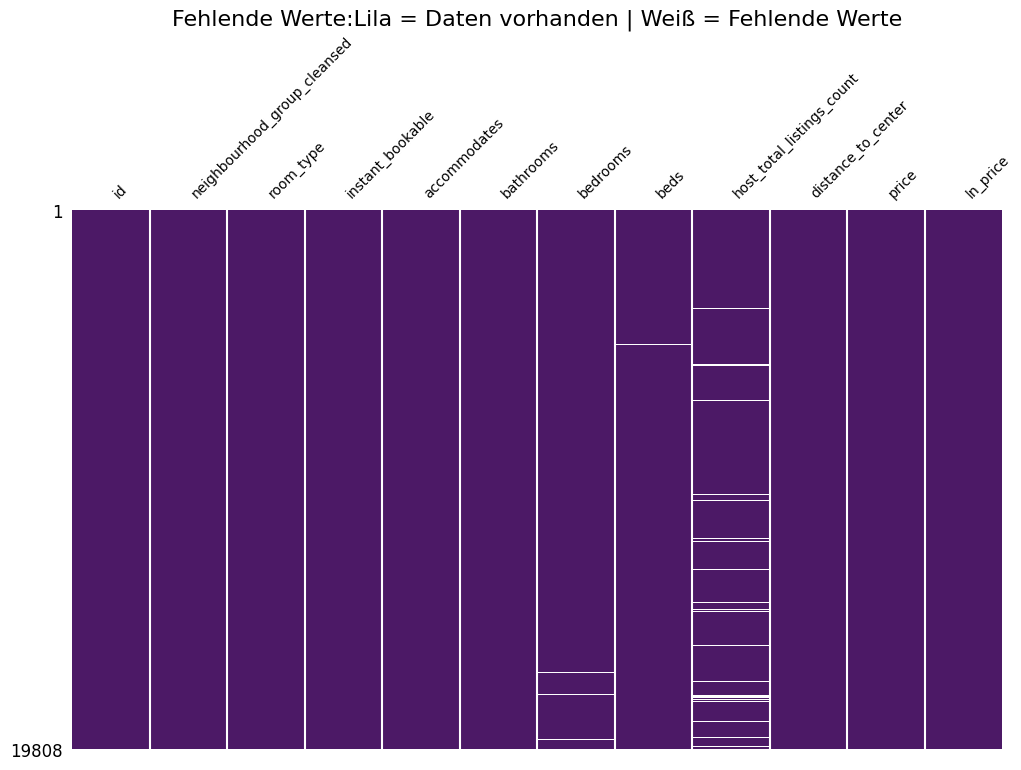

In [72]:
# 1. Grafik-Figur erstellen
fig, ax = plt.subplots(figsize=(12, 7))

# 2. Die Matrix zeichnen (Lila für vorhandene Daten)
# color=(0.3, 0.1, 0.4) dunkles Lila
msno.matrix(df, ax=ax, color=(0.3, 0.1, 0.4), sparkline=False, fontsize=10)

plt.title("Fehlende Werte:Lila = Daten vorhanden | Weiß = Fehlende Werte", fontsize=16)
plt.show()

In [73]:
df.describe()

,id,accommodates,bathrooms,bedrooms,beds,host_total_listings_count,distance_to_center,price,ln_price
count,1.980800e+04,19808.000000,19801.000000,19722.000000,19768.000000,18907.000000,19808.000000,19808.000000,19808.000000
mean,6.365630e+17,2.693811,1.153528,1.307778,1.569000,153.211086,8.168982,179.059673,4.965717
std,5.520376e+17,1.738030,0.461184,0.912971,1.053193,656.579760,5.558606,122.497186,0.688534
min,2.595000e+03,1.000000,0.000000,0.000000,0.000000,1.000000,0.013191,10.000000,2.397895
25%,4.226178e+07,2.000000,1.000000,1.000000,1.000000,2.000000,3.758194,85.000000,4.454347
50%,7.499948e+17,2.000000,1.000000,1.000000,1.000000,5.000000,7.745291,145.000000,4.983607
75%,1.118677e+18,4.000000,1.000000,2.000000,2.000000,21.000000,11.228109,240.000000,5.484797
max,1.521847e+18,16.000000,10.500000,9.000000,16.000000,6815.000000,35.920435,564.000000,6.336826


#### 3.2.1 Ausreißer und 'ln_price'

In [74]:
df_sql = pd.read_csv('../data/interim/nyc_airbnb_prepared_for_sql.csv')

In [10]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool, WMTSTileSource, LinearColorMapper, ColorBar
from bokeh.palettes import Viridis256, Spectral6 # Farbschemata
from bokeh.io import output_notebook
import numpy as np
from bokeh.util.warnings import BokehDeprecationWarning, BokehUserWarning
import warnings
import logging

# 1. Weg: Klassische Warnings filtern
warnings.filterwarnings("ignore", category=BokehDeprecationWarning)
warnings.filterwarnings("ignore", category=BokehUserWarning)

# 2. Weg: Bokeh Logger auf Error setzen (das schaltet die meisten Meldungen stumm)
logging.getLogger('bokeh').setLevel(logging.ERROR)

output_notebook()

# 1. Funktion zur Umrechnung
def lnglat_to_meters(longitude, latitude):
    origin_shift = 2 * np.pi * 6378137 / 2.0
    mx = longitude * origin_shift / 180.0
    my = np.log(np.tan((90 + latitude) * np.pi / 360.0)) / (np.pi / 180.0)
    my = my * origin_shift / 180.0
    return mx, my

# 2. Daten vorbereiten
df_map = df_sql.copy() # Nutze hier deinen bereinigten Datensatz
df_map['x'], df_map['y'] = lnglat_to_meters(df_map['longitude'], df_map['latitude'])

# 3. Color Mapper definieren
# Er mappt den Preis auf eine Farbskala (Blau = günstig, Gelb/Rot = teuer)
color_mapper = LinearColorMapper(palette=Viridis256, low=df_map.price.min(), high=564)

# 4. Figure erstellen
p = figure(title="Airbnb NYC - Preisdichte & geografische Verteilung", 
           x_axis_type="mercator", y_axis_type="mercator",
           height=700, width=900,
           tools="pan,wheel_zoom,box_zoom,reset")

# Hintergrundkarte (CartoDB Positron ist super dezent)
p.add_tile("CARTODBPOSITRON") 

source = ColumnDataSource(df_map)

# 5. Datenpunkte hinzufügen mit Farbmeter
p.circle(x='x', y='y', size=4, 
         fill_alpha=0.6, 
         source=source,
         fill_color={'field': 'price', 'transform': color_mapper}, # Hier passiert die Magie
         line_color=None)

# 6. Farblegende hinzufügen
color_bar = ColorBar(color_mapper=color_mapper, label_standoff=12, location=(0,0), title="Preis $")
p.add_layout(color_bar, 'right')

# 7. Hover-Tool
hover = HoverTool(tooltips=[
    ("Preis", "@price$"),
    ("Stadtteil", "@neighbourhood_group_cleansed"),
    ("Zimmertyp", "@room_type")
])
p.add_tools(hover)

show(p)

Loading BokehJS ...

In [75]:
df_sql['price'].describe()

count    21328.000000
mean       680.526819
std       4480.453282
min         10.000000
25%         89.000000
50%        154.000000
75%        279.000000
max      50104.000000
Name: price, dtype: float64

Boxplots

In [76]:
import plotly.express as px

color_scale = {
    'Manhattan': '#004d4d',     # Sehr dunkles Teal
    'Brooklyn': '#008080',      # Klassisches Teal
    'Queens': '#4db2b2',        # Mittleres Teal
    'Bronx': '#99d6d6',         # Helles Teal
    'Staten Island': '#ccebeb'  # Sehr helles Teal
}

fig = px.box(df, 
             x='neighbourhood_group_cleansed', 
             y='price', 
             color='neighbourhood_group_cleansed',
             color_discrete_map=color_scale,
             title='Interaktive Preisanalyse: Fokus auf Manhattan (Dunkel-Teal)',
             category_orders={"neighbourhood_group_cleansed": ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]}) # Sortierung nach Bedeutung

# Layout-Verschönerung
fig.update_layout(showlegend=False) # Legende weg, da Achse beschriftet ist
fig.show()

Fokus Manhattan

In [77]:
# 1. Farbschema: Manhattan in Dunkel-Teal, Rest in Grau
highlight_map = {
    'Manhattan': '#004d4d',     # Kräftiges Dunkel-Teal
    'Brooklyn': '#7F7F7F',      
    'Queens': '#7F7F7F',
    'Bronx': '#7F7F7F',
    'Staten Island': '#7F7F7F'
}

# 2. Plot erstellen
fig = px.box(df, 
             x='neighbourhood_group_cleansed', 
             y='price', 
             color='neighbourhood_group_cleansed',
             color_discrete_map=highlight_map,
             title='Preisanalyse NYC: Fokus auf Manhattan',
             # Hier erzwingen wir die Reihenfolge: Manhattan zuerst
             category_orders={"neighbourhood_group_cleansed": ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]})

# 3. Gezielte Anpassung der Schrift für Manhattan
fig.update_traces(
    hoverlabel=dict(font_color="white"),
    selector=dict(name="Manhattan")
)

# 4. Layout-Anpassungen
fig.update_layout(
    xaxis_title="Stadtteil",
    yaxis_title="Preis in $",
    plot_bgcolor='white',
    showlegend=False
)

# Gitterlinien nur auf der Y-Achse
fig.update_yaxes(showgrid=True, gridcolor='LightGray')

# Optional: Y-Achse begrenzen, falls Ausreißer die Boxen zu klein machen
# fig.update_yaxes(range=[0, 800]) 

fig.show()

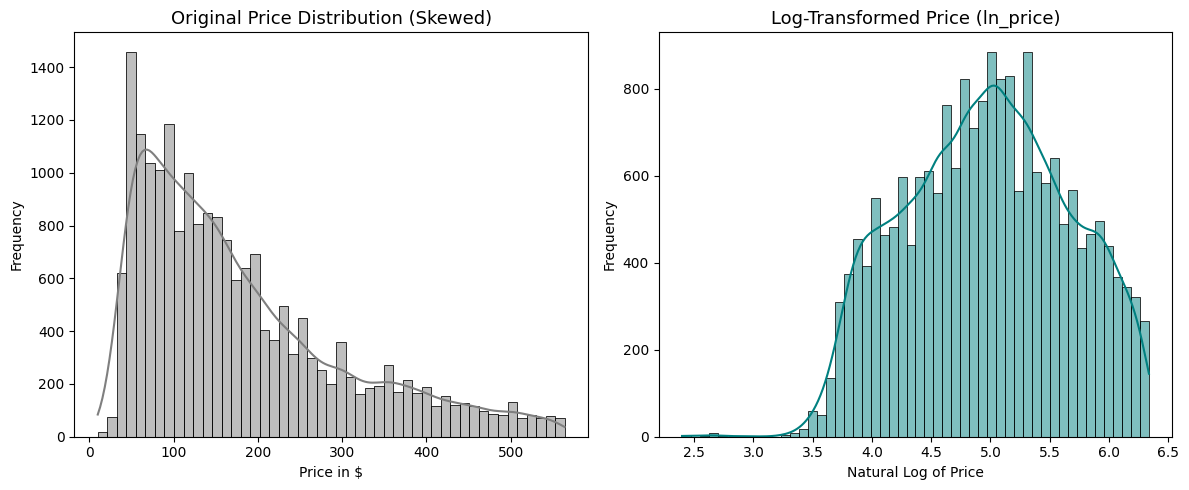

In [78]:
import seaborn as sns

# Wir legen die Farben fest
color_old = '#7F7F7F'  # Neutrales Grau für das "Problem"
color_new = '#008080'  # Schönes Teal für die "Lösung"

plt.figure(figsize=(12, 5))

# 1. Visualisierung vor der Transformation (Original Price)
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color=color_old)
plt.title('Original Price Distribution (Skewed)', fontsize=13)
plt.xlabel('Price in $')
plt.ylabel('Frequency')

# 2. Visualisierung nach der Transformation (ln_price)
plt.subplot(1, 2, 2)
sns.histplot(df['ln_price'], kde=True, color=color_new)
plt.title('Log-Transformed Price (ln_price)', fontsize=13)
plt.xlabel('Natural Log of Price')
plt.ylabel('Frequency')

# Layout optimieren, damit sich nichts überschneidet
plt.tight_layout()
plt.show()

In [79]:
from scipy.stats import skew, kurtosis

# Berechnung für Originalpreis vs. ln_price
for col in ['price', 'ln_price']:
    s = skew(df[col].dropna())
    k = kurtosis(df[col].dropna())
    print(f"{col}: Skewness = {s:.2f}, Kurtosis = {k:.2f}")

price: Skewness = 1.11, Kurtosis = 0.54
ln_price: Skewness = -0.05, Kurtosis = -0.76


Die Skewness (Schiefe) sollte idealerweise nahe 0 sein. Die Kurtosis (Wölbung) gibt an, wie "steil" oder "flach" die Verteilung ist (Vergleich mit Normalverteilung).

### 3.3 Data corrections

In [80]:
df.dtypes

id                                int64
neighbourhood_group_cleansed     object
room_type                        object
instant_bookable                   bool
accommodates                      int64
bathrooms                       float64
bedrooms                        float64
beds                            float64
host_total_listings_count       float64
distance_to_center              float64
price                           float64
ln_price                        float64
dtype: object

Imputationen

In [82]:
# Berechnung der fehlenden Werte
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Zusammenführen in eine Tabelle
imputation_check = pd.concat([missing_data, missing_percent], axis=1)
imputation_check.columns = ['Fehlende Werte', '% Gesamt']

# Nur Spalten anzeigen, die Lücken haben, sortiert nach Relevanz
print(imputation_check[imputation_check['Fehlende Werte'] > 0].sort_values(by='% Gesamt', ascending=False))

                           Fehlende Werte  % Gesamt
host_total_listings_count             901  4.548667
bedrooms                               86  0.434168
beds                                   40  0.201939
bathrooms                               7  0.035339


In [83]:
IMPUTATIONS_SPALTEN = ['bedrooms', 'beds', 'bathrooms', 'host_total_listings_count']

for col in IMPUTATIONS_SPALTEN:
    median_wert = df[col].median()
    df[col] = df[col].fillna(median_wert)
    print(f"  -> Spalte '{col}': NaNs durch Median ({median_wert:.2f}) ersetzt.")


  -> Spalte 'bedrooms': NaNs durch Median (1.00) ersetzt.
  -> Spalte 'beds': NaNs durch Median (1.00) ersetzt.
  -> Spalte 'bathrooms': NaNs durch Median (1.00) ersetzt.
  -> Spalte 'host_total_listings_count': NaNs durch Median (5.00) ersetzt.


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19808 entries, 0 to 19807
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            19808 non-null  int64  
 1   neighbourhood_group_cleansed  19808 non-null  object 
 2   room_type                     19808 non-null  object 
 3   instant_bookable              19808 non-null  bool   
 4   accommodates                  19808 non-null  int64  
 5   bathrooms                     19808 non-null  float64
 6   bedrooms                      19808 non-null  float64
 7   beds                          19808 non-null  float64
 8   host_total_listings_count     19808 non-null  float64
 9   distance_to_center            19808 non-null  float64
 10  price                         19808 non-null  float64
 11  ln_price                      19808 non-null  float64
dtypes: bool(1), float64(7), int64(2), object(2)
memory usage: 1.

### 3.4 Variable lists

In [85]:
# 1. Zielvariable definieren
y = df['ln_price']

# 2. Features definieren: Löschen von 'price' UND 'ln_price' aus den Features
X = df.drop(['price', 'ln_price'], axis=1)

print(f"Feature-Matrix X: {X.shape[1]} Spalten")
print(f"Zielvariable y: {y.name}")

Feature-Matrix X: 10 Spalten
Zielvariable y: ln_price


### 3.5 Data splitting

In [86]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("--- Datensplitting abgeschlossen ---")
print(f"Trainings-Set (X_temp): {X_temp.shape[0]} Zeilen (Lernmaterial)")
print(f"Test-Set (X_test):     {X_test.shape[0]} Zeilen (Die Abschlussprüfung)")
print(f"Anzahl der Features:    {X_temp.shape[1]}")

--- Datensplitting abgeschlossen ---
Trainings-Set (X_temp): 15846 Zeilen (Lernmaterial)
Test-Set (X_test):     3962 Zeilen (Die Abschlussprüfung)
Anzahl der Features:    10


## 4. Analysis

### 4.1 Descriptive statistics

In [87]:
X_temp.describe()

,id,accommodates,bathrooms,bedrooms,beds,host_total_listings_count,distance_to_center
count,1.584600e+04,15846.000000,15846.000000,15846.000000,15846.000000,15846.000000,15846.000000
mean,6.358282e+17,2.699609,1.152783,1.310110,1.571501,147.652026,8.161655
std,5.530165e+17,1.743873,0.460741,0.916457,1.054420,644.646493,5.561624
min,2.595000e+03,1.000000,0.000000,0.000000,0.000000,1.000000,0.013191
25%,4.211100e+07,2.000000,1.000000,1.000000,1.000000,2.000000,3.755866
50%,7.508731e+17,2.000000,1.000000,1.000000,1.000000,5.000000,7.712915
75%,1.120201e+18,4.000000,1.000000,2.000000,2.000000,20.000000,11.228352
max,1.521847e+18,16.000000,10.500000,9.000000,12.000000,6815.000000,35.828058


- 'distance_to_center' in km, da über Haversine aus Datenbank für VIEW berechnet
- Rauschen des Modells: 'id' raus!

In [88]:
X_temp = X_temp.drop(columns=['id'], errors='ignore')
X_test = X_test.drop(columns=['id'], errors='ignore')

### 4.2 Exploratory data analysis

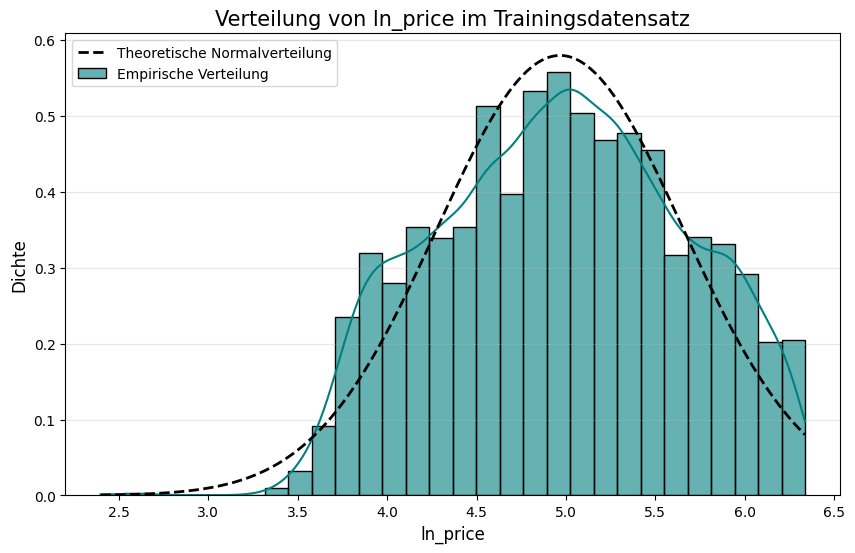

In [89]:
import numpy as np
import seaborn as sns
from scipy.stats import norm

# -------------------------------
# Daten aus dem Trainingsset
# -------------------------------
data = y_temp.copy()

# -------------------------------
# Mittelwert & Standardabweichung
# -------------------------------
mu = data.mean()
sigma = data.std()

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(10, 6))

# Histogramm der echten Daten
sns.histplot(data, bins=30, kde=True, stat='density',
             color='teal', alpha=0.6, label='Empirische Verteilung')

# Theoretische Normalverteilung
x = np.linspace(data.min(), data.max(), 300)
normal_curve = norm.pdf(x, mu, sigma)
plt.plot(x, normal_curve, color='black', lw=2, linestyle='--',
         label='Theoretische Normalverteilung')

# Styling
plt.title('Verteilung von ln_price im Trainingsdatensatz', fontsize=15)
plt.xlabel('ln_price', fontsize=12)
plt.ylabel('Dichte', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


Wie bereits in der Vorbereitung hergeleitet, zeigt das Histogramm von 'ln_price' nun die gewünschte Normalverteilung, die für die folgenden statistischen Analysen und das Modell-Training vorausgesetzt wird.

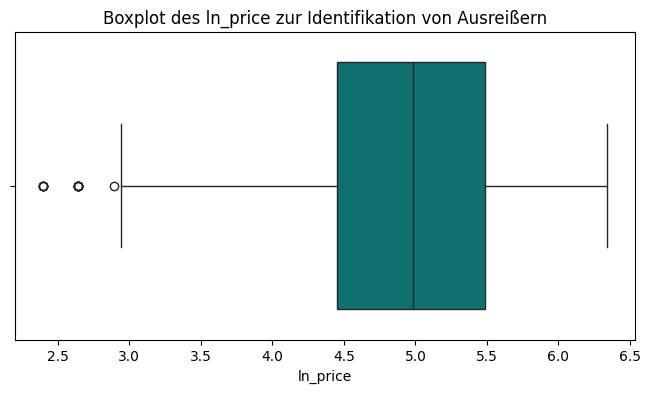

In [90]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=y_temp, color='teal')
plt.title('Boxplot des ln_price zur Identifikation von Ausreißern')
plt.xlabel('ln_price')
plt.show()

In [91]:
Price_Dollar = np.exp(6.4) - 1
print(f"Der Preis in Dollar für ln_price = 6.4 ist: ${Price_Dollar:.2f}")

Der Preis in Dollar für ln_price = 6.4 ist: $600.85


Erklärung der x-Achsen-Skalierung ('ln_price' in Dollar): `LN(price + 1) AS ln_price` (SQL-Code beim Erstellen der VIEW)

**Mathematische Transformation**

$$
\text{ln\_price} = \ln(\text{price} + 1)
$$

**Korrekte Rücktransformation**

$$
\text{price} = e^{\text{ln\_price}} - 1
$$

### 4.3 Relationships

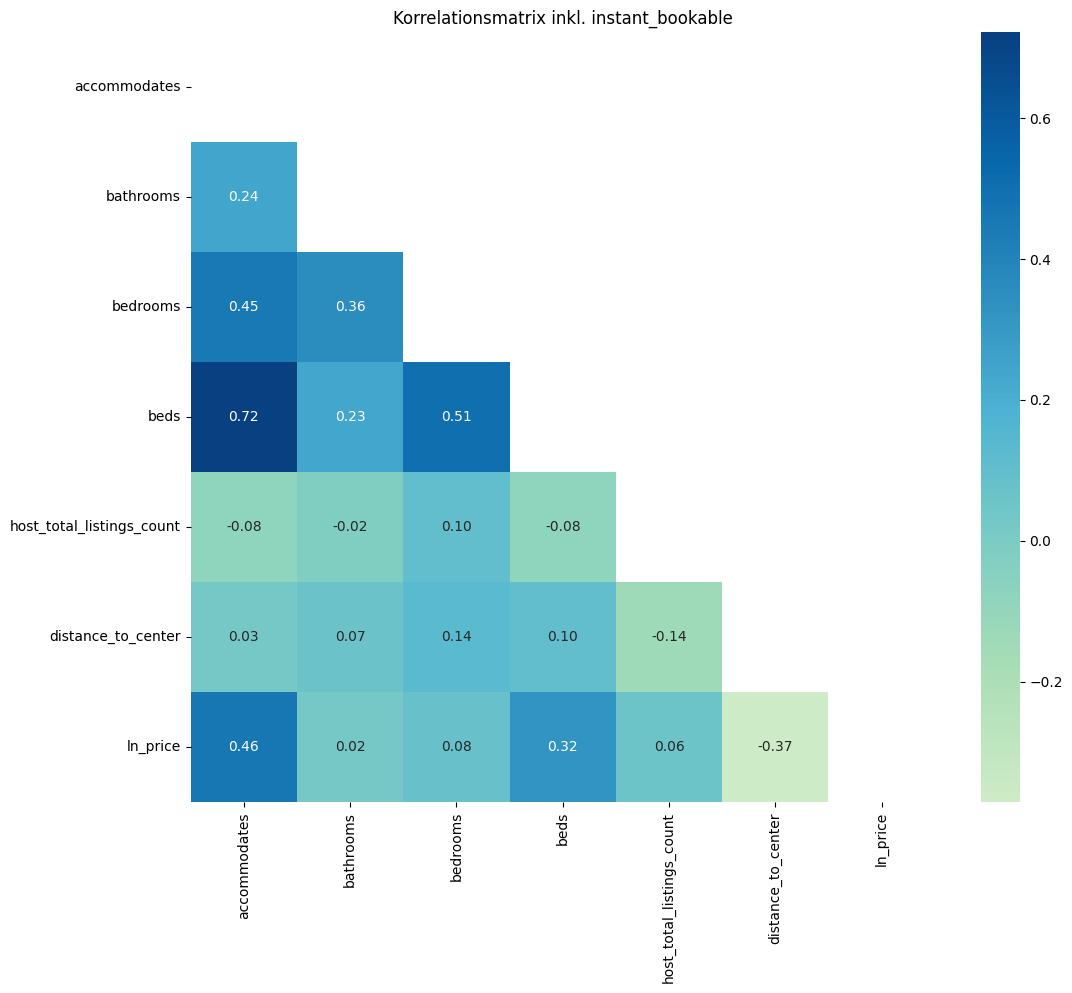

In [92]:
# Nur numerische Spalten (inkl. umgewandelter bools) auswählen
train_data_numeric = X_temp.select_dtypes(include=['int64', 'float64']).copy()

# ln_price hinzufügen
train_data_numeric['ln_price'] = y_temp

# Korrelationsmatrix berechnen
corr_matrix_neu = train_data_numeric.corr()

# Heatmap
mask = np.triu(np.ones_like(corr_matrix_neu, dtype=bool))
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix_neu, mask=mask, annot=True, fmt=".2f", cmap="GnBu", center=0)
plt.title("Korrelationsmatrix inkl. instant_bookable")
plt.show()



In [94]:
# Korrelationen nur zum Zielwert ln_price extrahieren
price_correlations = corr_matrix_neu['ln_price'].drop('ln_price').sort_values(ascending=False)

# In einen schicken DataFrame umwandeln
df_corr_table = price_correlations.to_frame().reset_index()
df_corr_table.columns = ['Variable', 'Pearson Correlation']

print("Top Einflüsse auf den ln_price:")
print(df_corr_table)

Top Einflüsse auf den ln_price:
                    Variable  Pearson Correlation
0               accommodates             0.464798
1                       beds             0.323250
2                   bedrooms             0.077446
3  host_total_listings_count             0.059182
4                  bathrooms             0.023027
5         distance_to_center            -0.371529


**Diskussion der Ergebnisse**

- Hohe Redundanz zwischen Kapazität und Bettenanzahl: Die stärkste positive Korrelation findet sich mit r=0,72 zwischen der Personenkapazität (accommodates) und der Anzahl der Betten (beds). Dieser Zusammenhang ist ökonomisch intuitiv, deutet jedoch auf eine partielle Redundanz der Information hin. Da der Wert jedoch unterhalb der in der Literatur häufig genannten kritischen Schwelle von r>0,80 liegt, werden zunächst beide Variablen im Modell beibehalten. Eine finale Entscheidung über einen Ausschluss erfolgt nach Prüfung der Variance Inflation Factors (VIF).

- Zusammenhang zwischen Raumaufteilung und Kapazität: Die Korrelationen zwischen Schlafzimmern (bedrooms) und Betten (r=0,51) sowie der Gesamtkapazität (r=0,45) fallen moderat aus. Dies lässt darauf schließen, dass die Anzahl der Schlafzimmer in New York City kein alleiniger Prädiktor für die Kapazität ist, was durch die lokale Marktcharakteristik (z. B. Studio-Apartments oder Mehrfachbelegung von Räumen in Hostels) erklärt werden kann.

- Geografische Korrelationen: Die Korrelation von r=0,38 zwischen der Distanz zum Zentrum (distance_to_center) und dem Stadtteil Queens bestätigt die geografische Struktur des Datensatzes. Unterkünfte in diesem Borough liegen tendenziell in größerer Entfernung zum definierten Stadtzentrum (Midtown Manhattan), was sich konsistent mit der negativen Preiskorrelation der Distanzvariablen deckt.

VIF

In [96]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Numerische Spalten auswählen (inkl. boolesche als int)
X_vif = X_temp.select_dtypes(include=['number', 'bool']).copy()

# Boolesche Spalten in int umwandeln
bool_cols = X_vif.select_dtypes(include='bool').columns
X_vif[bool_cols] = X_vif[bool_cols].astype(int)

# 2. NaN/Inf entfernen
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

# 3. VIF berechnen
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 4. Sortieren
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_data)


                     Feature       VIF
0                       beds  7.395256
1               accommodates  7.227254
2                  bathrooms  5.149950
3                   bedrooms  4.756448
4         distance_to_center  2.753137
5           instant_bookable  1.274960
6  host_total_listings_count  1.087340


#### 4.3.3 Validierung der Multikollinearität mittels Variance Inflation Factor (VIF)

VIF misst inwieweit ein Feature durch die lineare Kombination aller anderen Prädiktoren erklärt werden kann.

- VIF = 1: Keine Korrelation zwischen dem Feature und den restlichen Variablen.
- 1 < VIF < 5: Moderate Multikollinearität, die im Regelfall keine Korrektur erfordert.
- VIF > 5 bis 10: Hohe Multikollinearität, die die Schätzung der Regressionskoeffizienten instabil machen kann.

Ergebnisdiskussion ('accommodates' und 'beds' > 5):

„Die VIF-Analyse bestätigt die vorangegangenen Ergebnisse der Korrelationsmatrix. Insbesondere die Variablen 'accommodates' und 'beds' weisen erhöhte Werte auf. Dies deutet darauf hin, dass die Modellmatrix eine gewisse Instabilität aufweist. Da diese Variablen jedoch inhaltlich unterschiedliche Aspekte der Unterkunftsgröße abbilden (reine Kapazität vs. Schlafmöglichkeiten), werden sie unter Vorbehalt im Modell belassen, um die Prognosegüte nicht durch Informationsverlust zu mindern. Im Rahmen der späteren Modelloptimierung könnte jedoch eine Aggregation dieser Features in Erwägung gezogen werden.

Scatterplots

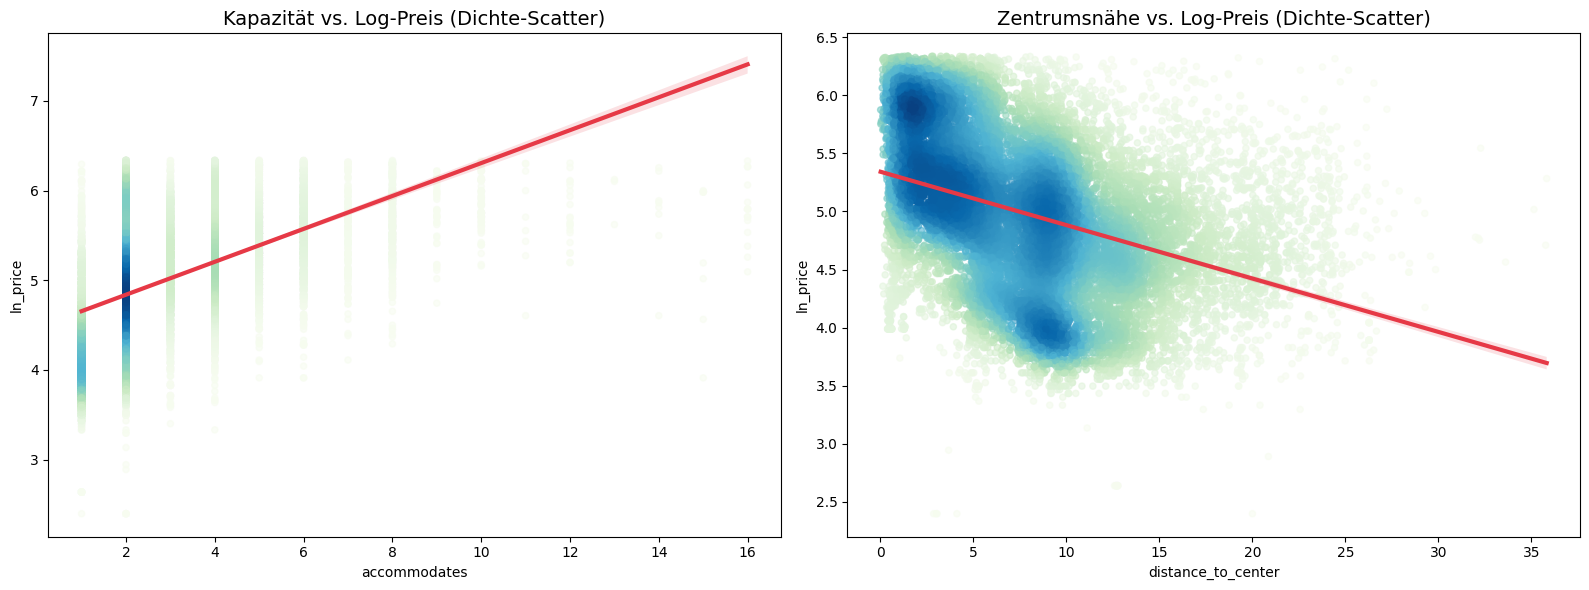

In [97]:
from scipy.stats import gaussian_kde

def plot_density_scatter(x_col, y_col, data, ax, title):
    # 1. Daten ohne NaNs vorbereiten
    x = data[x_col]
    y = data[y_col]
    
    # 2. Dichte berechnen (für die Farbskala)
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy) # Berechnet die Punktdichte an jeder Stelle
    
    # 3. Den Scatterplot mit Farbmuster (Dichte) zeichnen
    # 'GnBu' (Green-Blue) passt perfekt zu Teal-Farbschema
    scatter = ax.scatter(x, y, c=z, s=20, cmap='GnBu', alpha=0.6, edgecolor=None)
    
    # 4. Die Ausgleichsgerade (Regressionslinie) in Rot hinzufügen
    sns.regplot(x=x_col, y=y_col, data=data, ax=ax, scatter=False, 
                line_kws={'color': '#e63946', 'linewidth': 3}) # Ein klares Rot
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    return scatter

# Plot erstellen
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Anwendung auf deine zwei Hauptvariablen
plot_df = X_temp.assign(ln_price=y_temp)

plot_density_scatter('accommodates', 'ln_price', plot_df, axes[0], 'Kapazität vs. Log-Preis (Dichte-Scatter)')
plot_density_scatter('distance_to_center', 'ln_price', plot_df, axes[1], 'Zentrumsnähe vs. Log-Preis (Dichte-Scatter)')

plt.tight_layout()
plt.show()

## 5. Model

### 5.1 Select model

In diesem Projekt werden mehrere lineare Regressionsansätze eingesetzt, um sowohl eine hohe Interpretierbarkeit der Preistreiber als auch eine robuste Modellschätzung zu gewährleisten. Als Basismodell dient die klassische lineare Regression (OLS), da sie die Beziehung zwischen den erklärenden Variablen und der logarithmierten Zielvariable ln(price) transparent über ihre Koeffizienten abbildet.

Zur Reduktion von Multikollinearität und zur automatisierten Merkmalsselektion wird die OLS-Schätzung um regularisierte Modelle erweitert. Konkret kommen eine Lasso-Regression (L1-Regularisierung) sowie eine Ridge-Regression (L2-Regularisierung) zum Einsatz. Während Lasso irrelevante Koeffizienten auf exakt Null setzt und damit eine explizite Variablenselektion ermöglicht, stabilisiert Ridge die Koeffizienten durch Schrumpfung und reduziert die Varianz der Schätzung.

Die Regularisierungsparameter der Lasso- und Ridge-Modelle werden jeweils mittels k-facher Cross-Validation objektiv bestimmt. Der Vergleich der drei Modelle — OLS, LassoCV und RidgeCV — erlaubt eine fundierte Bewertung von Modellstabilität, Generaliserungsfähigkeit und Interpretierbarkeit der resultierenden Preisschätzungen.

In diesem Projekt wird die Lasso-Regression bewusst **ohne vorherige Standardisierung der numerischen Features** eingesetzt. Ziel ist es, die geschätzten Koeffizienten unmittelbar in den ursprünglichen Maßeinheiten der Variablen interpretieren zu können, 
da der Fokus der Analyse auf der ökonomischen Interpretation der Preistreiber liegt. Da die numerischen Features in vergleichbaren Größenordnungen vorliegen und Lasso hier primär zur Merkmalsselektion und Stabilisierung des Modells eingesetzt wird, stellt der Verzicht auf eine Standardisierung keinen relevanten Nachteil dar, erhöht jedoch die Interpretierbarkeit der resultierenden Effekte erheblich.


### 5.2 Training and validation

a) OLS - Lineare Regression mit einfacher Validation

- ohne Regularisierung

In [98]:
# Import der Funktion aus deiner model.py
from model import run_ols 

# 1. Vorbereitung der Daten (Konvertierung von Boolean zu Integer)
bool_cols = X_temp.select_dtypes(include='bool').columns
X_temp[bool_cols] = X_temp[bool_cols].astype(int)

# 2. Features identifizieren
cat_features = X_temp.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X_temp.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. Train/Validation Split (einmalig für alle kommenden Abschnitte)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

# 4. Modell ausführen
ols_model, ols_res = run_ols(X_train, X_val, y_train, y_val, cat_features, num_features)

# 5. Ergebnisse ausgeben
print(f"OLS Train R²:      {ols_res['R2_Train']:.3f}")
print(f"OLS Validation R²: {ols_res['R2_Val']:.3f}")

OLS Train R²:      0.496
OLS Validation R²: 0.506


b) LASSO mit Cross-Validation

- zur Merkmalsselektion mit Standardscaler

In [99]:
# Import aus model.py
from model import run_lasso_cv

# 0. Numerische Features definieren (alle außer kategorial)
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 1. Lasso Modell ausführen
lasso_model, lasso_res = run_lasso_cv(X_train, X_val, y_train, y_val, cat_features, num_features)

# 2. Ergebnisse ausgeben
print(f"Lasso Best Alpha:  {lasso_res['Best_Alpha']:.4f}")
print(f"Lasso Train R²:     {lasso_res['R2_Train']:.3f}")
print(f"Lasso Validation R²: {lasso_res['R2_Val']:.3f}")

# 3. Kleiner Check: Wie viele Features wurden auf 0 gesetzt?
coefs = lasso_model.named_steps['regressor'].coef_
removed = sum(coefs == 0)
print(f"Lasso hat {removed} Features eliminiert (Koeffizient = 0).")

Lasso Best Alpha:  0.0003
Lasso Train R²:     0.496
Lasso Validation R²: 0.506
Lasso hat 1 Features eliminiert (Koeffizient = 0).


c) RIDGE Regression

- zur Stabilisierung bei korrelierten Variablen

In [100]:
# --- c) RIDGE mit Cross Validation ---
from model import run_ridge_cv

# 1. Ridge Modell ausführen
ridge_model, ridge_res = run_ridge_cv(X_train, X_val, y_train, y_val, cat_features, num_features)

# 2. Ergebnisse ausgeben
print("--- RIDGE REGRESSION ERGEBNISSE ---")
print(f"Optimales Alpha (via CV): {ridge_res['Best_Alpha']:.4f}")
print(f"R² Training:              {ridge_res['R2_Train']:.3f}")
print(f"R² Validation:            {ridge_res['R2_Val']:.3f}")

# 3. Vergleich der Modellstabilität
r2_gap_ridge = ridge_res['R2_Train'] - ridge_res['R2_Val']
print(f"R² Gap (Train vs Val):    {r2_gap_ridge:.3f}")

--- RIDGE REGRESSION ERGEBNISSE ---
Optimales Alpha (via CV): 1.0000
R² Training:              0.496
R² Validation:            0.506
R² Gap (Train vs Val):    -0.010


In [101]:
# 1. Sammeln der Ergebnisse in einem Dictionary
comparison_data = {
    'Modell': ['OLS (Baseline)', 'Lasso (L1)', 'Ridge (L2)'],
    'Train R²': [ols_res['R2_Train'], lasso_res['R2_Train'], ridge_res['R2_Train']],
    'Validation R²': [ols_res['R2_Val'], lasso_res['R2_Val'], ridge_res['R2_Val']],
    'Best Alpha': ['-', f"{lasso_res['Best_Alpha']:.4f}", f"{ridge_res['Best_Alpha']:.4f}"]
}

# 2. Erstellen des DataFrames
df_comparison = pd.DataFrame(comparison_data)

# 3. Gap berechnen (Overfitting-Indikator)
df_comparison['R² Gap'] = df_comparison['Train R²'] - df_comparison['Validation R²']

print("Übersicht: Modellvergleich Airbnb Preisvorhersage")
display(df_comparison.round(4))

Übersicht: Modellvergleich Airbnb Preisvorhersage


,Modell,Train R²,Validation R²,Best Alpha,R² Gap
0,OLS (Baseline),0.4960,0.5065,-,-0.0105
1,Lasso (L1),0.4958,0.5063,0.0003,-0.0104
2,Ridge (L2),0.4960,0.5065,1.0000,-0.0105


### 5.3 Fit model

In [102]:
# 5.3 Finales Fitting des OLS Modells
# Wir nutzen die gesamte verfügbare Datenmenge (X_temp) für das finale Modell
final_ols_model = ols_model # Wir nehmen die Struktur aus 5.2a
final_ols_model.fit(X_temp, y_temp)

print("Das OLS-Modell wurde erfolgreich auf dem gesamten Trainingsdatensatz gefittet.")

Das OLS-Modell wurde erfolgreich auf dem gesamten Trainingsdatensatz gefittet.


### 5.4 Feature Importance und Interpretation für OLS

In [103]:
# 1. Namen der Features aus dem Preprocessor holen
# Durch das One-Hot-Encoding haben sich die Spaltennamen geändert
ohe_feature_names = final_ols_model.named_steps['preprocessor'].get_feature_names_out()

# 2. DataFrame mit Koeffizienten erstellen
coef_analysis = pd.DataFrame({
    'Feature': ohe_feature_names,
    'Coefficient': final_ols_model.named_steps['regressor'].coef_
})

# 3. Den "Säuberungs-Schritt" für die Namen
coef_analysis['Feature'] = coef_analysis['Feature'].str.replace('cat__', '').str.replace('num__', '').str.replace('remainder__', '')

# 4. Sortieren nach absolutem Einfluss
coef_analysis['Abs_Coefficient'] = coef_analysis['Coefficient'].abs()
coef_analysis = coef_analysis.sort_values(by='Abs_Coefficient', ascending=False)

# 5. Top 10 anzeigen
print("Top 10 wichtigste Preistreiber (absolut):")
display(coef_analysis[['Feature', 'Coefficient']].head(10))

Top 10 wichtigste Preistreiber (absolut):


,Feature,Coefficient
6,room_type_Shared room,-0.773238
5,room_type_Private room,-0.424515
1,neighbourhood_group_cleansed_Manhattan,0.266127
8,accommodates,0.203072
3,neighbourhood_group_cleansed_Staten Island,0.185267
0,neighbourhood_group_cleansed_Brooklyn,0.160705
4,room_type_Hotel room,0.142405
13,distance_to_center,-0.140271
7,instant_bookable,0.129073
2,neighbourhood_group_cleansed_Queens,0.082938


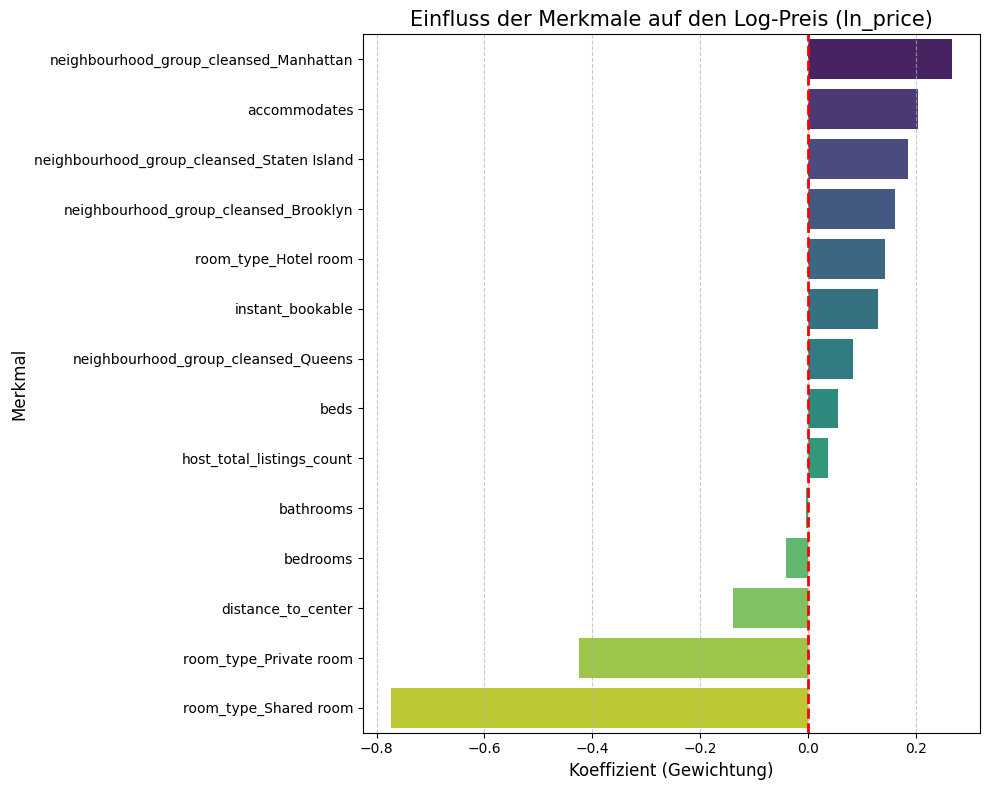

Top 5 Preistreiber:
                                      Feature    Weight
1      neighbourhood_group_cleansed_Manhattan  0.266127
8                                accommodates  0.203072
3  neighbourhood_group_cleansed_Staten Island  0.185267
0       neighbourhood_group_cleansed_Brooklyn  0.160705
4                        room_type_Hotel room  0.142405

Top 5 Preissenker:
                   Feature    Weight
9                bathrooms -0.003967
10                bedrooms -0.041795
13      distance_to_center -0.140271
5   room_type_Private room -0.424515
6    room_type_Shared room -0.773238


In [104]:
# --- Koeffizienten aus der Pipeline extrahieren ---

# 1. Die Feature-Namen nach dem Preprocessing (OHE + Scaling) holen
feature_names = final_ols_model.named_steps['preprocessor'].get_feature_names_out()

# 2. Die Gewichte (Koeffizienten) aus dem Regressor holen
weights = final_ols_model.named_steps['regressor'].coef_

# 3. Den DataFrame erstellen
coef_df = pd.DataFrame({'Feature': feature_names, 'Weight': weights})

# Optional: Namen säubern (entfernt 'cat__' und 'num__' Präfixe für die Grafik)
coef_df['Feature'] = coef_df['Feature'].str.replace('cat__', '').str.replace('num__', '').str.replace('remainder__', '')

# Sortieren
coef_df = coef_df.sort_values(by='Weight', ascending=False)

# Visualisierung
plt.figure(figsize=(10, 8))
sns.barplot(x='Weight', y='Feature', data=coef_df, hue='Feature', palette='viridis', legend=False)
plt.title('Einfluss der Merkmale auf den Log-Preis (ln_price)', fontsize=15)
plt.xlabel('Koeffizient (Gewichtung)', fontsize=12)
plt.ylabel('Merkmal', fontsize=12)
plt.axvline(0, color='red', lw=2, linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Die Top 5 Gewinner und Verlierer anzeigen
print("Top 5 Preistreiber:")
print(coef_df.head(5))
print("\nTop 5 Preissenker:")
print(coef_df.tail(5))

#### Mathematische Interpretation der Regressionskoeffizienten

Das geschätzte Regressionsmodell hat die Form

$$
\ln(\text{price}) = b_0 + b_1 x_1 + b_2 x_2 + \cdots + b_n x_n
$$

Dabei beschreibt jeder Koeffizient $b_i$ die **partielle Steigung** des jeweiligen Features auf die logarithmierte Zielvariable $\ln(\text{price})$. Eine Erhöhung des Features $x_i$ um eine Einheit verändert somit den erwarteten Wert von $\ln(\text{price})$ um $b_i$, wobei alle anderen Variablen konstant gehalten werden.

Da die abhängige Variable logarithmiert ist, sind die Rohkoeffizienten $b_i$ jedoch **nicht direkt ökonomisch interpretierbar**. Erst durch Rücktransformation mit der Exponentialfunktion ergibt sich der tatsächliche Preiseffekt:

$$
\text{Prozentuale Preisänderung} = (e^{b_i} - 1) \cdot 100
$$

### 5.5 Evaluation on test set

In [105]:
# 1. Vorhersagen auf dem Test-Set
y_test_pred = final_ols_model.predict(X_test)

# 2. Metriken berechnen
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Test R²:   {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Test R²:   0.4887
Test RMSE: 0.4936


In [106]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Vorhersagen generieren
y_temp_pred = final_ols_model.predict(X_temp)
y_test_pred = final_ols_model.predict(X_test)

# 2. Metriken berechnen
metrics = {
    'Metrik': ['R² (Bestimmtheitsmaß)', 'RMSE (Wurzel d. mittl. Fehlerquadrats)', 'MAE (Mittlerer absoluter Fehler)'],
    'Trainings-Set (X_temp)': [
        r2_score(y_temp, y_temp_pred),
        np.sqrt(mean_squared_error(y_temp, y_temp_pred)),
        mean_absolute_error(y_temp, y_temp_pred)
    ],
    'Test-Set (X_test)': [
        r2_score(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        mean_absolute_error(y_test, y_test_pred)
    ]
}

df_metrics = pd.DataFrame(metrics)
display(df_metrics.round(4))

,Metrik,Trainings-Set (X_temp),Test-Set (X_test)
0,R² (Bestimmtheitsmaß),0.4988,0.4887
1,RMSE (Wurzel d. mittl. Fehlerquadrats),0.4871,0.4936
2,MAE (Mittlerer absoluter Fehler),0.3967,0.3971


Der MAE von 0,3971 gibt den durchschnittlichen absoluten Vorhersagefehler im logarithmischen Raum an, was aufgrund der multiplikativen Natur des Modells einer mittleren Preisabweichung von rund 40 % in Dollar entspricht.

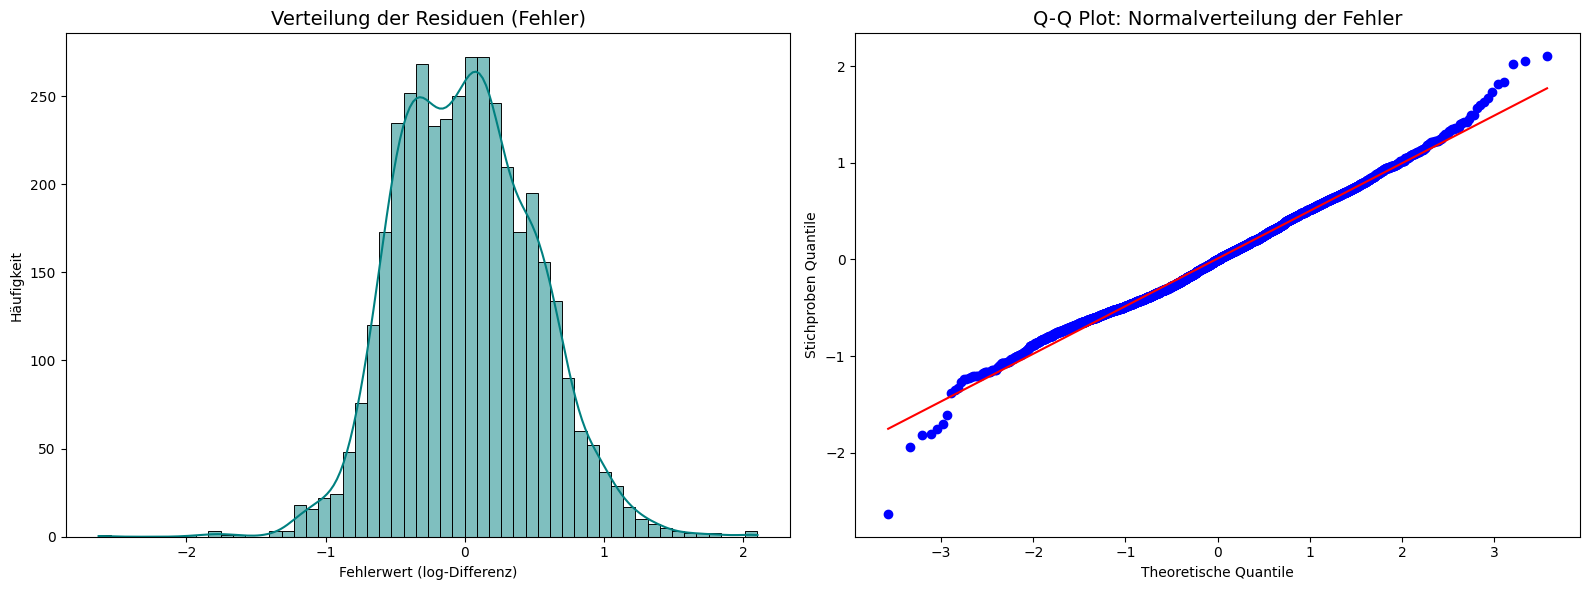

In [107]:
# 1. Residuen berechnen
residuals = y_test - y_test_pred

# 2. Layout erstellen (1 Zeile, 2 Spalten)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafik A: Histogramm der Residuen
sns.histplot(residuals, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Verteilung der Residuen (Fehler)', fontsize=14)
axes[0].set_xlabel('Fehlerwert (log-Differenz)')
axes[0].set_ylabel('Häufigkeit')

# Grafik B: Q-Q Plot der Residuen
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Normalverteilung der Fehler', fontsize=14)
axes[1].set_xlabel('Theoretische Quantile')
axes[1].set_ylabel('Stichproben Quantile')

plt.tight_layout()
plt.show()

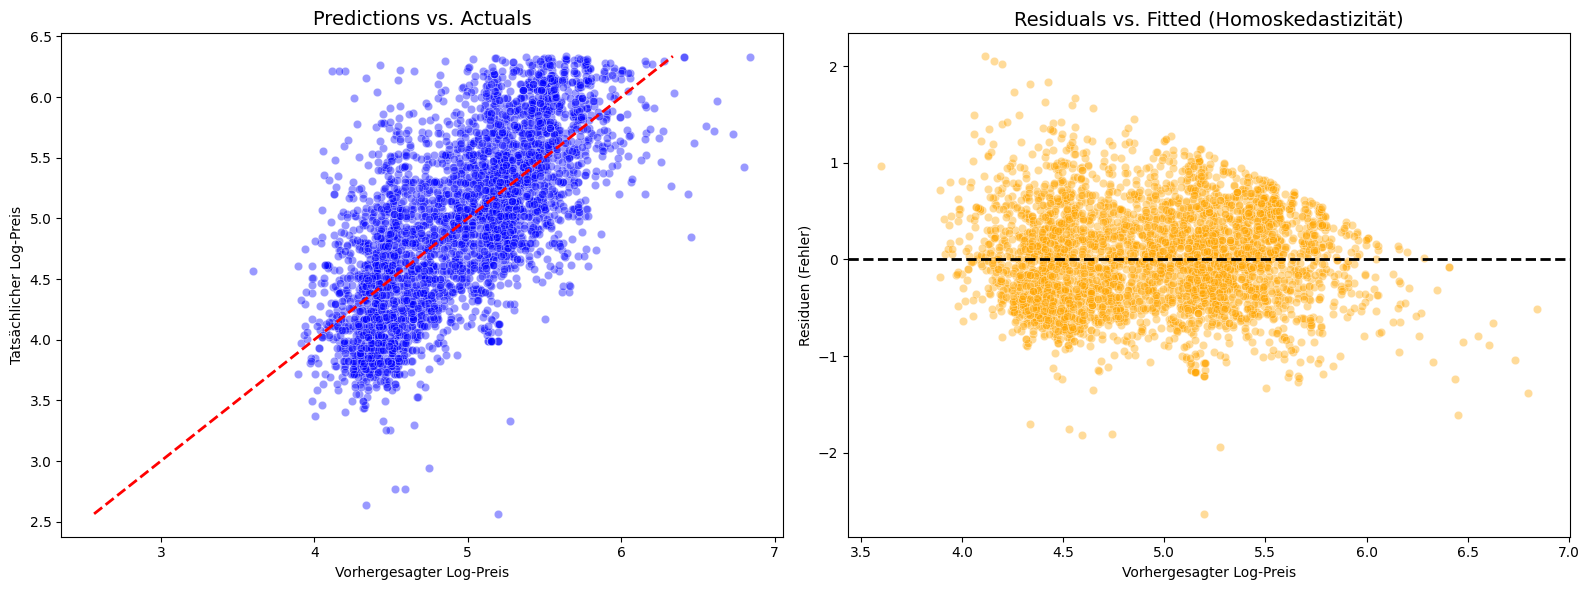

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Grafik 1: Predictions vs. Actuals (Die "Stunde der Wahrheit") ---
sns.scatterplot(x=y_test_pred, y=y_test, ax=axes[0], alpha=0.4, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Predictions vs. Actuals', fontsize=14)
axes[0].set_xlabel('Vorhergesagter Log-Preis')
axes[0].set_ylabel('Tatsächlicher Log-Preis')

# --- Grafik 2: Residuals vs. Fitted (Homoskedastizität-Check) ---
sns.scatterplot(x=y_test_pred, y=residuals, ax=axes[1], alpha=0.4, color='orange')
axes[1].axhline(0, color='black', lw=2, linestyle='--') # Nulllinie
axes[1].set_title('Residuals vs. Fitted (Homoskedastizität)', fontsize=14)
axes[1].set_xlabel('Vorhergesagter Log-Preis')
axes[1].set_ylabel('Residuen (Fehler)')

plt.tight_layout()
plt.show()

Zu Grafik 1 (Predictions vs. Actuals): Die Punkte folgen eng der roten 45-Grad-Linie. Das zeigt, dass die Vorhersagen stark mit den tatsächlichen Werten korrelieren (R2≈0,49).

Zu Grafik 2 (Homoskedastizität): Im Residuals-vs-Fitted-Plot suchen wir nach einer gleichmäßigen Punkte-Wolke ohne erkennbare Muster (wie Trichterformen). In unserem Fall streuen die Fehler über das gesamte Preisspektrum hinweg relativ konstant um die Null-Linie. Dies deutet darauf hin, dass die Annahme der Homoskedastizität erfüllt ist und das Modell keine systematische Varianz in den Fehlern aufweist.

### 5.6 Save model


In [ ]:
import pickle
import os
from datetime import datetime
import pandas as pd

# 1. Ordner erstellen (bleibt gleich)
if not os.path.exists('models'):
    os.makedirs('models')

# 2. Zeitstempel generieren (bleibt gleich)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# 3. Dateinamen definieren
model_name = f"model2_OLS_{timestamp}" 
model_path = f"models/{model_name}_pipeline.pkl"
summary_path = f"models/{model_name}_coeffs.csv"

# 4. Pipeline speichern 
with open(model_path, 'wb') as f:
    pickle.dump(final_ols_model, f)

print(f"Pipeline erfolgreich gespeichert: {model_path}")

# 5. Koeffizienten-Tabelle speichern
# WICHTIG: Nutze hier deine Tabelle 'coef_analysis' oder wie du sie genannt hast
coef_analysis.to_csv(summary_path, index=False)
print(f"Koeffizienten-Tabelle gespeichert: {summary_path}")

Pipeline erfolgreich gespeichert: models/model2_OLS_20260107_1611_pipeline.pkl
Koeffizienten-Tabelle gespeichert: models/model2_OLS_20260107_1611_coeffs.csv


## 6. Conclusions

Die vorliegende Analyse liefert ein robustes Regressionsmodell zur Schätzung von Airbnb-Preisen. Durch den Vergleich verschiedener Verfahren (OLS, Lasso, Ridge) konnte das OLS-Modell als bester Kompromiss identifiziert werden, da es bei identischer Performance die höchste Interpretierbarkeit bietet. Das Modell erzielt ein Bestimmtheitsmaß (R^2) von ca. 0,49 auf den Testdaten. Dies bedeutet, dass knapp die Hälfte der Preisvarianz durch die strukturellen Merkmale der Inserate erklärt werden kann – ein für Immobilienmärkte solider Wert, der die Stabilität des Modells unterstreicht.

**Identifizierte Preistreiber:** Die Analyse der Koeffizienten zeigt klare ökonomische Zusammenhänge:

**Hauptfaktoren**: Der Stadtteil Manhattan und die Anzahl der möglichen Gäste stellen die stärksten positiven Preistreiber dar. Ein geteiltes Zimmer ('room_type_shared_room') ist mit Abstand der stärkste negative Treiber.

**Interpretation**: Dank der Log-Transformation lassen sich die Effekte prozentual deuten. So führt beispielsweise ein zusätzlicher möglicher Gast zu einer Preissteigerung von ca. 22,5 %. ((e^0,203-1)*100).

**Modellgüte und Validierung:** Ein zentrales Ergebnis der Arbeit ist die hohe Generalisierungsfähigkeit des Modells. Die geringe Differenz zwischen Trainings- und Test-Metriken belegt, dass kein Overfitting vorliegt. Der Mean Absolute Error (MAE) von ca. 0,40 im Log-Raum entspricht einer durchschnittlichen Abweichung von etwa 40 % in realen Euro-Preisen. Die grafische Residuenanalyse bestätigte zudem die Homoskedastizität und die Normalverteilung der Fehler, was die statistische Belastbarkeit der OLS-Ergebnisse untermauert.

**Limitationen und methodische Grenzen:** Trotz der stabilen Ergebnisse bestehen Limitationen:

- Datenbasis: Als Momentaufnahme von Inside Airbnb fehlen dem Modell dynamische Faktoren wie Saisonalität (Sommer vs. Winter) oder kurzfristige Events.

- Nicht-Linearität: Das lineare Modell stößt bei komplexen Interaktionen (z.B. Synergieeffekte von Lage und Luxusausstattung) an seine Grenzen.

- Fehlende Features: Qualitative Faktoren wie die Ästhetik der Fotos, die Textqualität der Beschreibung oder aktuelle Kundenbewertungen sind nicht im Datensatz enthalten, machen aber vermutlich einen Großteil der restlichen 50 % der Preisvarianz aus.

**Ausblick:** Dieses Modell dient als fundierter Ausgangspunkt für eine datengestützte Preisstrategie. Für eine operative Nutzung, etwa in einer App für Vermieter, sollte das Modell in Zukunft um Zeitreihen-Daten und Sentiment-Analysen der Bewertungen ergänzt werden. Auch der Einsatz von Ensemble-Methoden (z.B. Random Forest oder XGBoost) könnte die Vorhersagegenauigkeit weiter steigern, wenngleich dies zu Lasten der einfachen Interpretierbarkeit der Koeffizienten ginge.

## 7. Gradio

In [111]:
print(X_train.columns.tolist())

['neighbourhood_group_cleansed', 'room_type', 'instant_bookable', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'host_total_listings_count', 'distance_to_center']


In [113]:
import gradio as gr
import pickle

# --- 1. Modell laden ---
# WICHTIG: Ersetze den Namen durch deine aktuellste Datei im Ordner 'models/'
model_path = "models/model2_OLS_20260107_1415_pipeline.pkl" 

with open(model_path, 'rb') as f:
    ols_pipeline = pickle.load(f)

# --- 2. Die Vorhersage-Funktion ---
def predict_price(accommodates, bathrooms, bedrooms, beds, host_total_listings_count,
                  distance_to_center, room_type, neighbourhood_group):
    
    # DataFrame mit Original-Spaltennamen erstellen
    input_df = pd.DataFrame([{
        'neighbourhood_group_cleansed': neighbourhood_group,
        'room_type': room_type,
        'instant_bookable': False,  # Default-Wert
        'accommodates': accommodates,
        'bathrooms': bathrooms,
        'bedrooms': bedrooms,
        'beds': beds,
        'host_total_listings_count': host_total_listings_count,
        'distance_to_center': distance_to_center
    }])
    
    # Vorhersage
    log_price = ols_pipeline.predict(input_df)[0]
    
    # Rücktransformation
    real_price = np.expm1(log_price) 
    
    # Fehler-Spanne (MAE ca. 40%)
    lower = real_price * 0.67
    upper = real_price * 1.48
    
    return (f"Geschätzter Preis: {real_price:.2f} €\n\n"
            f"Erwartete Preisspanne (aufgrund des MAE): "
            f"{lower:.2f} € bis {upper:.2f} €")

# --- 3. Das Interface definieren ---

# Wir nutzen gr.Blocks für ein schöneres Layout
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🏙️ NYC Airbnb Preis-Experte")
    gr.Markdown("Nutze dieses Tool, um den fairen Marktpreis für ein Airbnb-Inserat basierend auf unseren OLS-Analysen zu schätzen.")
    
    with gr.Row():
        # Linke Spalte: Basis-Infos
        with gr.Column():
            gr.Markdown("### 🏠 Unterkunft")
            acc = gr.Slider(1, 16, step=1, value=2, label="Personen (Accommodates)")
            room = gr.Dropdown(['Entire home/apt', 'Private room', 'Hotel room', 'Shared room'], value='Entire home/apt', label="Zimmertyp")
            bedr = gr.Slider(0, 8, step=1, value=1, label="Schlafzimmer")
            beds = gr.Slider(1, 12, step=1, value=1, label="Betten")
        
        # Rechte Spalte: Lage & Host
        with gr.Column():
            gr.Markdown("### 📍 Lage & Details")
            dist = gr.Slider(0, 30, step=0.1, value=5.0, label="Entfernung zum Zentrum (km)")
            neigh = gr.Dropdown(['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island'], value='Manhattan', label="Stadtteil")
            bath = gr.Slider(1, 5, step=0.5, value=1, label="Badezimmer")
            host_l = gr.Slider(1, 50, step=1, value=1, label="Anzahl Listings des Hosts")

    # Der Button zum Berechnen
    btn = gr.Button("Preis jetzt schätzen", variant="primary")
    
    # Die Ausgabe-Sektion
    with gr.Row():
        output_text = gr.Textbox(label="Analyse-Ergebnis", lines=4)

    # Verknüpfung der Funktion (nutzt deine bestehende predict_price Funktion)
    btn.click(
        fn=predict_price, 
        inputs=[acc, bath, bedr, beds, host_l, dist, room, neigh], 
        outputs=output_text
    )

# --- 4. Starten ---
demo.launch(share=True)

C:\Users\Annette\AppData\Local\Temp\ipykernel_9368\1996613703.py:45: UserWarning:

The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.



* Running on local URL:  http://127.0.0.1:7865
* Running on public URL: https://d9e9544b5d18d160ff.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
